In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import os

In [2]:
rave_sim_dir = Path('/mnt/d/rave-sim-main/rave-sim-main')
simulations_dir = Path('/mnt/d/rave-sim-main/rave-sim-main/output')
scratch_dir = simulations_dir

In [3]:
sys.path.insert(0, str(rave_sim_dir / "big-wave"))
import multisim
import config
import util

In [4]:
# ===== 扫参：扫描 z_detector 位置，验证 2D 传播的 1/r² 强度衰减 =====

# z_detector 扫描范围（从 0.5 m 到 2.0 m）
z_distances = [0.5, 1.0, 1.5, 2.0]  # 扫描 4 个距离 (Python float)

# 存储结果
center_intensities = []
all_wavefronts = []

for iz, z_det in enumerate(z_distances):
    z_det = float(z_det)  # 确保 Python float
    print(f"\n{'='*60}")
    print(f"[{iz+1}/{len(z_distances)}] z_detector = {z_det:.1f} m")
    print('='*60)
    
    config_dict = {
        "sim_params": {
            "is2d": 'true',
            "N": 16384 * 16384,
            "nx": 16384,
            "ny": 16384,
            "dx": 6.0e-8,          # 65 nm (z=0.5m 时的频率约束: dx < λ·z / detector_size)
            "z_detector": z_det,   # 扫描参数
            "detector_size": 0.85e-3,
            "detector_size_y": 0.85e-3,
            "detector_pixel_size_x": 2e-7,
            "detector_pixel_size_y": 2e-7,
            "chunk_size": 2*1024*1024*1024 // 16,
        },
        "use_disk_vector": False,
        "save_final_u_vectors": False,
        "dtype": "c8",
        "multisource": {
            "type": "points",
            "energy_range": [9999, 10001],
            "x_range": [-1e-6, 1e-6],
            "y_range": [-1e-6, 1e-6],
            "z": 0.0,
            "nr_source_points": 1,
            "seed": 1,
        },
        "elements": [
            # 空场，无样品，测试纯传播
        ],
    }
    
    # 设置仿真
    sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)
    computed = config.load(Path(sim_path / 'computed.yaml'))
    
    # 运行仿真
    for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
        os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")
    
    # 加载波场
    wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-30e-6, 30e-6))
    wavef = [result[0] for result in wavefronts]
    wf = np.sum(wavef, axis=0)
    
    # 提取中心强度（中心 100x100 像素平均）
    det = wf[0].astype(np.float64)
    ny, nx = det.shape
    cy, cx = ny // 2, nx // 2
    center_mean = det[cy-50:cy+50, cx-50:cx+50].mean()
    center_intensities.append(center_mean)
    all_wavefronts.append(det)
    
    print(f"  Center intensity: {center_mean:.4e}")
    
    # 保存该距离的波场到文件
    from contextlib import redirect_stdout
    with open(f'output_distance_z_{z_det:.1f}m.txt', 'w') as file:
        with redirect_stdout(file):
            for row in range(len(det)):
                print(det[row])
    print(f"  Saved output_distance_z_{z_det:.1f}m.txt")

print(f"\n{'='*60}")
print("Scan complete!")
print(f"z_distances: {z_distances}")
print(f"center_intensities: {center_intensities}")
print('='*60)

2026-05-31 11:53:30,605 INFO: Setting up simulation
2026-05-31 11:53:30,607 INFO: 2D mode: nx=16384, ny=16384, dx=6.000e-08, dy=6.000e-08, detector=(8.500e-04 x 8.500e-04) m
2026-05-31 11:53:30,608 INFO: 2D Nyquist check: dz=5.000e-01, x: Nx=16384, dx=6.000e-08, x_source=-1.000e-06 | y: Ny=16384, dy=6.000e-08, y_source=1.000e-06
2026-05-31 11:53:30,638 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/05/20260531_115330612634



[1/4] z_detector = 0.5 m


  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2026-05-31 11:53:30.819] [info] Detector 2D mode
[2026-05-31 11:53:30.819] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/05/20260531_115330612634/00000000
[2026-05-31 11:53:30.819] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-05-31 11:53:30.819] [info] GPU memory required for wavefield: 2048 MB
[2026-05-31 11:53:31.283] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-05-31 11:53:46.399] [info]   Number of optical elements: 0
[2026-05-31 11:53:58.903] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-05-31 11:53:58.903] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07
[2026-05-31 11:53:58.903] [info]   current_z=0.5, dx=6e-08, dy=6e-08


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:28<00:00, 28.94s/it]

...

2026-05-31 11:55:32,848 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/05/20260531_115532823602
  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2026-05-31 11:55:32.992] [info] Detector 2D mode
[2026-05-31 11:55:32.992] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/05/20260531_115532823602/00000000
[2026-05-31 11:55:32.992] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-05-31 11:55:32.992] [info] GPU memory required for wavefield: 2048 MB
[2026-05-31 11:55:33.352] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-05-31 11:55:47.362] [info]   Number of optical elements: 0
[2026-05-31 11:56:00.474] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-05-31 11:56:00.474] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07
[2026-05-31 11:56:00.474] [info]   current_z=2, dx=6e-08, dy=6e-08


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:28<00:00, 28.27s/it]

[2026-05-31 11:56:01.056] [info] 2D Simulation finished in 28.985847738 seconds


  Center intensity: 9.9893e-15
  Saved output_distance_z_2.0m.txt

Scan complete!
z_distances: [0.5, 1.0, 1.5, 2.0]
center_intensities: [1.5971680668698747e-13, 3.993787375243958e-14, 1.7754399707548995e-14, 9.989294616231112e-15]


2D 空场传播 1/r² 验证
  z (m)      I_center             I*z²                 deviation 
------------------------------------------------------------
  0.5        1.5972e-13           3.9929e-14           -3.43%    
  1.0        3.9938e-14           3.9938e-14           -1.26%    
  1.5        1.7754e-14           3.9947e-14           +1.12%    
  2.0        9.9893e-15           3.9957e-14           +3.57%    
------------------------------------------------------------
  I*z² = 3.9943e-14 ± 1.0453e-17  (rsd = 0.03%)


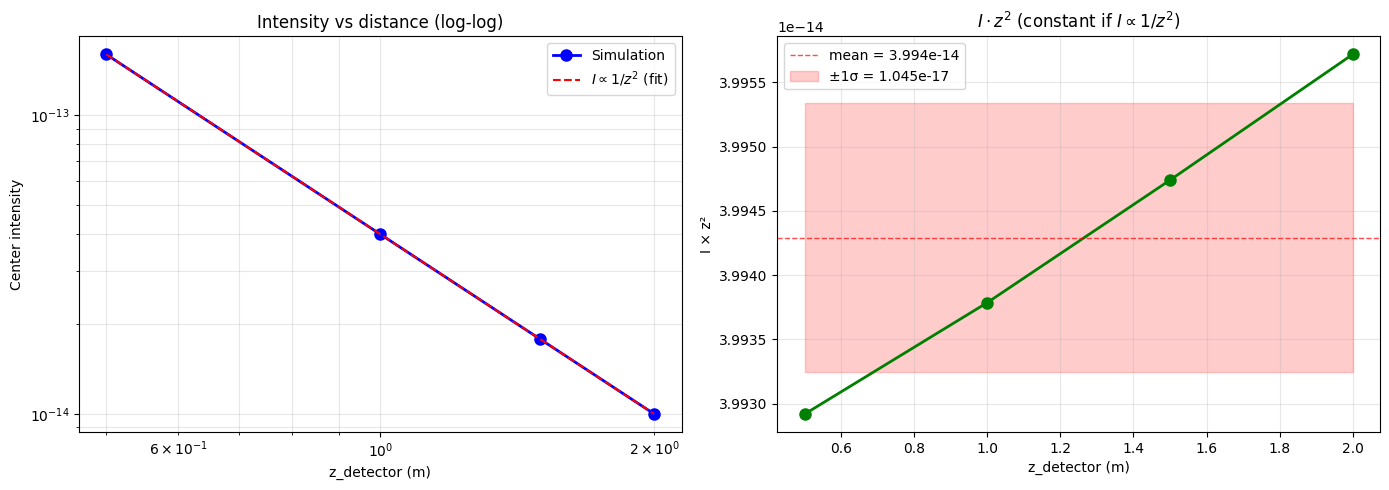

Saved distance_r_test_analysis.png


In [5]:
# ===== 分析：1/r² 拟合 =====
center_intensities = np.array(center_intensities)
z_distances = np.array(z_distances)

# 理论：I ∝ 1/z²  →  I * z² = constant
Iz2 = center_intensities * z_distances**2
const_mean = Iz2.mean()
const_std = Iz2.std()

print("=" * 60)
print("2D 空场传播 1/r² 验证")
print("=" * 60)
print(f"  {'z (m)':<10} {'I_center':<20} {'I*z²':<20} {'deviation':<10}")
print("-" * 60)
for z, I in zip(z_distances, center_intensities):
    dev = (I * z**2 / const_mean - 1) * 100
    print(f"  {z:<10.1f} {I:<20.4e} {I*z**2:<20.4e} {dev:<+10.2%}")
print("-" * 60)
print(f"  I*z² = {const_mean:.4e} ± {const_std:.4e}  (rsd = {const_std/const_mean:.2%})")

# 对数坐标图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：log(I) vs log(z)
ax = axes[0]
ax.loglog(z_distances, center_intensities, 'bo-', lw=2, markersize=8, label='Simulation')
# 理论参考线：1/r²
z_fit = np.linspace(z_distances.min(), z_distances.max(), 100)
I_fit = const_mean / z_fit**2
ax.loglog(z_fit, I_fit, 'r--', lw=1.5, label=r'$I \propto 1/z^2$ (fit)')
ax.set_xlabel('z_detector (m)')
ax.set_ylabel('Center intensity')
ax.set_title('Intensity vs distance (log-log)')
ax.legend()
ax.grid(alpha=0.3, which='both')

# 右图：I*z² vs z（应为常数）
ax = axes[1]
ax.plot(z_distances, Iz2, 'go-', lw=2, markersize=8)
ax.axhline(const_mean, color='r', ls='--', lw=1, alpha=0.7, label=f'mean = {const_mean:.3e}')
ax.fill_between(z_distances, const_mean - const_std, const_mean + const_std,
                alpha=0.2, color='r', label=f'±1σ = {const_std:.3e}')
ax.set_xlabel('z_detector (m)')
ax.set_ylabel(r'I × z²')
ax.set_title(r'$I \cdot z^2$ (constant if $I \propto 1/z^2$)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('distance_r_test_analysis.png', dpi=150)
plt.show()
print('Saved distance_r_test_analysis.png')

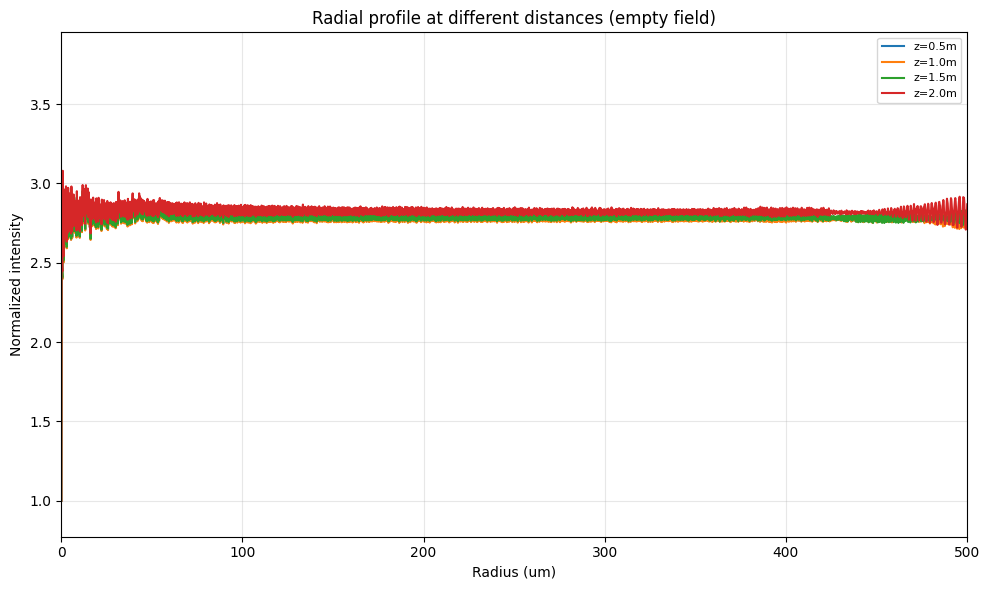

Saved distance_r_radial_profiles.png


In [5]:
# ===== 径向分布随距离变化 =====
fig, ax = plt.subplots(figsize=(10, 6))

det_pixel_um = 0.2  # 200 nm -> um

for iz, (z, det) in enumerate(zip(z_distances, all_wavefronts)):
    ny, nx = det.shape
    cy, cx = ny // 2, nx // 2
    yy, xx = np.ogrid[:ny, :nx]
    rr = np.sqrt((xx - cx)**2 + (yy - cy)**2).astype(np.int32)
    r_max = int(rr.max()) + 1
    radial_I = np.bincount(rr.ravel(), weights=det.ravel()) / np.bincount(rr.ravel())
    r_um = np.arange(r_max) * det_pixel_um
    
    # 归一化到中心
    radial_norm = radial_I / radial_I[0]
    ax.plot(r_um, radial_norm, lw=1.5, label=f'z={z:.1f}m')

ax.set_xlabel('Radius (um)')
ax.set_ylabel('Normalized intensity')
ax.set_title('Radial profile at different distances (empty field)')
ax.legend(fontsize=8)
ax.set_xlim(0, 500)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('distance_r_radial_profiles.png', dpi=150)
plt.show()
print('Saved distance_r_radial_profiles.png')

In [6]:
# ===== 与空场 detected.npy 对比 =====
# 如果有之前保存的 detected.npy，直接读取对比
# 加载 z=4.0m 的 detected.npy（应该和 wf[0] 一致）

# 列出仿真输出目录
print("Empty field simulation output directories:")
for p in sorted(Path(simulations_dir / "2026" / "05").glob("20260517_130720366449/*")):
    detected_file = p / "detected.npy"
    if detected_file.exists():
        det_ref = np.load(detected_file).squeeze().astype(np.float64)
        print(f"  {p.name}: shape={det_ref.shape}, mean={det_ref.mean():.3e}")
    else:
        print(f"  {p.name}: no detected.npy")

print("\nDone.")

Empty field simulation output directories:
  00000000: shape=(4250, 4250), mean=2.507e-15
  computed.yaml: no detected.npy
  config.yaml: no detected.npy

Done.


In [7]:
# ===== 最终汇总 =====
print("=" * 60)
print("Distance_r_test 完成")
print("=" * 60)
print(f"扫描距离: {z_distances[0]:.1f} - {z_distances[-1]:.1f} m, 共 {len(z_distances)} 个点")
print()
print(f"1/r² 验证结果:")
print(f"  I*z² = {const_mean:.4e} ± {const_std:.4e}")
print(f"  相对标准差 = {const_std/const_mean:.2%}")
print()
if const_std/const_mean < 0.05:
    print("✅ 结论: 强度衰减符合 1/r² (偏差 < 5%)")
elif const_std/const_mean < 0.10:
    print("⚠️ 结论: 强度衰减基本符合 1/r² (偏差 < 10%)")
else:
    print("❌ 结论: 强度衰减偏离 1/r² (偏差 > 10%)")
print()
print("文件输出:")
print("  distance_r_test_analysis.png  - I(z) 曲线 + I*z² 常数检验")
print("  distance_r_radial_profiles.png - 径向分布随距离变化")
print("  output_distance_z_*.txt       - 各距离的波场数据")

Distance_r_test 完成
扫描距离: 0.5 - 2.0 m, 共 4 个点

1/r² 验证结果:


NameError: name 'const_mean' is not defined